In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pickle
from matplotlib.colors import ListedColormap

## Problem: PO

Given $N$ stocks and a fixed bugdet to spend, what are the portions of the budget to assign to each stock to maximise return $\mu$ while minimizing the risk $\Sigma$? The granularity is a parameter $w$.

The Quadratic Unconstrained INTEGER Optimization model can be formulated in the following way

\begin{align}
	H = \sum_{i, j=1}^{N} (\gamma  \Sigma_{i,j} - \delta_{ij}\mu_{i}) \tilde x_{i} \tilde x_{j}  + M \bigg[ \sum_{i=1}^{N} \tilde x_i - (2^w - 1)  \bigg]^2\, ,
\end{align}

where $\gamma$ is the risk aversion factor, the decision variable $\tilde x \in \{0, \cdots, 2^w-1\}^N$ is a vector of integers, one for each stock, that indicates how many equal portions of the $2^w-1$ to invest in each stock. The constraint enforces that the total portions of the stocks sum up to $2^w - 1$.

In order to be mapped to a binary problem, each integer variable $\tilde x_i \in \{0, \cdots, 2^w-1\}$ can be expressed using $w$ bits via: $\tilde x_i = \sum_{k = 0}^{w-1} 2^k x^{(i)}_k$.

In the QUBO reformulation, if we want to keep just the binary variables as bits while incorporating the powers of $2$ in the problem matrix, we can rewrite them in the following way. Only for the return $\mu$ will be showed for semplicity: we want to go from $\mu_{(int)} \in \mathbb R ^N \to \mu_{(bin)} \in \mathbb R ^{wN}$. First we repeat $w$ times each entry of $\mu_{(int)}$, then we entry-wise multiply it by the scaler $A = N \textit{ times }[2^{w-1}, 2^{w-2}, \cdots, 2^1, 2^0]$, to get in the end $\mu_{(bin)} = [2^{w-1} \mu_{(int)}[0], 2^{w-2} \mu_{(int)}[0], \cdots, 2^0 \mu_{(int)}[0], 2^{w-1} \mu_{(int)}[1], \cdots, \cdots, 2^{0} \mu_{(int)}[N-1]]$.


- $N$: Number of stocks.
- $w$: Granularity: each ratio can be described to a precision of $(2^w-1)^{-1}$, and you need $w$ qubits per stock
- ${\rm{bits}} = Nw*$: Number of bits needed to represent problem QUBO.
- $M$: Penalty factor.


Expanding the Hamiltonians $H = H_o + M H_p$, using now BINARY variables, the Quadratic Unconstrained Binary Optimization model can be formulated in the following way, where $A_{(bin)} \in \mathbb N ^{wN}, \;\mu_{(bin)} \in \mathbb R ^{wN}, \; \Sigma_{(bin)} \in \mathbb R ^{wN \times wN}$ and we characterized the constraints elements $A_{(bin)i} = 2^{w - 1 - i\%w}$, $b = 2^w - 1$, so that the constraint can be expressed as $Ax = b$.

$$
H_o =  \sum_{i, j=1}^{Nw}  (\gamma  \Sigma_{(bin)i,j} - \delta_{ij}\mu_{(bin)i}) x_{i}x_{j}
$$

$$
H_p = \bigg[ \sum_{i=1}^{N} \tilde x_i - b  \bigg]^2 = b^2 + \sum_{i}^{Nw} \biggl(-2 b A_{(bin)i} \biggr)x_{i} + \sum_{i, j}^{Nw} A_{(bin)i} A_{(bin)j} x_i x_j
$$

In [2]:
### nice plots

import matplotlib as matp

matp.rcParams['mathtext.fontset'] = 'stix'
matp.rcParams['font.family'] = 'STIXGeneral'

## Read data for analysis

In [12]:
class Datas():
    def __init__(self, bits_idx_list, n_temp_scalers, n_eta_runs):
        N_stocks = np.array([2, 4, 6, 8, 10, 15, 20, 30, 40, 50, 60])
        self.w = 5
        self.directory = "PO_big"
        vseeds = range(42, 943, 100)

        self.Ns = N_stocks[bits_idx_list]
        self.bits = self.Ns[bits_idx_list] * self.w
        self.vseeds = vseeds
        self.n_vseeds = len(vseeds)
        self.temperature_scalers = [1, 10, 100, 1000]
        self.temperature_base = 1e3
        self.temperatures_labels = ["$10^3$", "$10^4$", "$10^5$", "$10^6$"] # = temp_base * temp_scalers

        self.M_star = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, n_eta_runs))
        self.M_L1 = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, n_eta_runs))
        self.temperature = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers))
        self.eta_required = np.array([.25, .5, .75])

In [16]:
# change last_Nidx to extend your dataset as you collect more data

last_Nidx = 8
N_stocks = np.array([2, 4, 6, 8, 10, 15, 20, 30, 40])
N_idxs = np.arange(last_Nidx+1)
n_temp_scalers = 4
n_eta_runs = 3
data = Datas(N_idxs, n_temp_scalers, n_eta_runs)


directory = "../data/Ms_PO/"

for N_idx in N_idxs: # if N_idxs start from 0. Else, write "for N_idx_idx, N_idx in enumerate(N_idxs):"
    filename = directory + f"results-N={N_stocks[N_idx]}_w={data.w}.txt"
    file = open(filename, "rb")
    D = pickle.load(file)
    file.close()

    assert len(D.keys()) == len(data.vseeds)
    for seed_idx, seed in enumerate(D):
        assert len(D[seed].keys()) == n_temp_scalers
        for temp_idx, temp_scaler in enumerate(list(D[seed])):
            data.temperature[N_idx, seed_idx, temp_idx] = D[seed][temp_scaler]["temperature"]
            assert len(D[seed][temp_scaler].keys()) == n_eta_runs + 1  # the +1 is for temperature
            for eta_run_idx, eta_req in enumerate(list(D[seed][temp_scaler])[1:]):
                data.M_star[N_idx, seed_idx, temp_idx, eta_run_idx] = D[seed][temp_scaler][eta_req]["M_star"]
                data.M_L1[N_idx, seed_idx, temp_idx, eta_run_idx] = D[seed][temp_scaler][eta_req]["M_L1"]

## $log( M_{\ell_1} / M^*)(n_{bits})$ for different temperatures

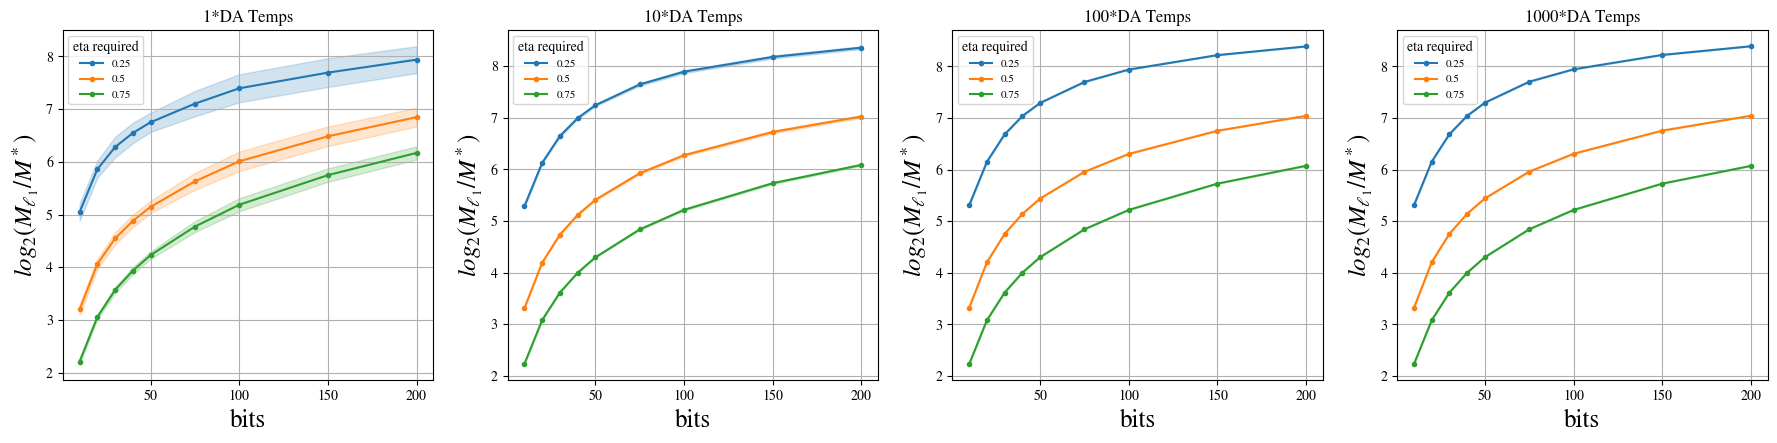

In [17]:
fig = plt.figure(figsize=(22,10))
for temp_idx in range(n_temp_scalers):
    logs = np.mean(  np.log2(data.M_L1[:, :, temp_idx, ...] / data.M_star[:, :, temp_idx, ...])  , axis = 1)
    logs_std = np.std(  np.log2(data.M_L1[:, :, temp_idx, ...] / data.M_star[:, :, temp_idx, ...]) , axis = 1)
    
    ax = fig.add_subplot(2,4,temp_idx+1)
    ax.set_xlabel('bits', fontsize = 18)
    ax.set_ylabel(r'$log_2( M_{\ell_1} / M^*)$', fontsize = 18)

    for eta_run_idx in np.arange(n_eta_runs):
        ax.plot(data.bits, logs[:, eta_run_idx], "-", marker = ".", color = f"C{eta_run_idx}", label=str(data.eta_required[eta_run_idx]))
        ax.fill_between(data.bits, logs[:, eta_run_idx] - logs_std[:, eta_run_idx], logs[:, eta_run_idx] + logs_std[:, eta_run_idx], color = f"C{eta_run_idx}", alpha=.2)
    #ax.set_xscale("log")
    ax.set_title(f"{data.temperature_scalers[temp_idx]}*DA Temps")
    ax.legend(title = "eta required", fontsize = 8, loc='best')
    ax.grid()
plt.show()

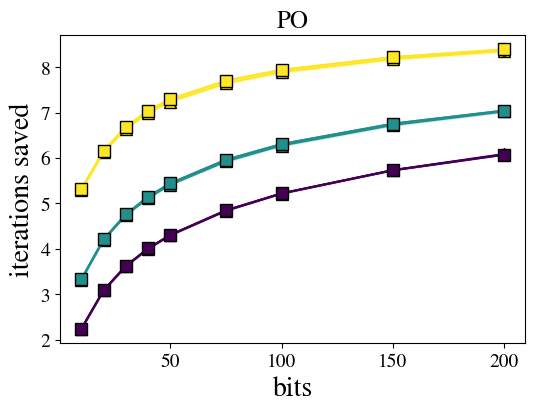

In [ ]:
# markers = ["x", "^", "o", "s"]
# colormap = plt.cm.viridis.reversed()
# discr_colors = ListedColormap(colormap(np.linspace(0, 1, n_eta_runs))) 

# exc_temp = 1

# fig = plt.figure(figsize=(6,4))
# ax = fig.add_subplot(111)
# ax.set_xlabel(r'bits', fontsize = 20)
# #ax.set_ylabel(r'$log_2( M_{\ell_1} / M^*)$', fontsize = 20)
# ax.set_ylabel(r'iterations saved', fontsize = 20)
# ax.tick_params(axis='both', labelsize=14)
# # ax.set_xticks(data.bits)
# for temp_idx in range(exc_temp, n_temp_scalers):
#     for eta_run_idx in np.arange(n_eta_runs):
#         logs = np.mean(  np.log2(data.M_L1[:, :, temp_idx, eta_run_idx] / data.M_star[:, :, temp_idx, eta_run_idx])  , axis = 1)
#         logs_std = np.std(  np.log2(data.M_L1[:, :, temp_idx, eta_run_idx] / data.M_star[:, :, temp_idx, eta_run_idx]) , axis = 1)
#         ax.plot(data.bits, logs, "-", color = discr_colors.colors[eta_run_idx], marker = markers[temp_idx], markersize = 8, markeredgecolor="k",
#                  label=str(data.eta_required[eta_run_idx]) + f" ; {data.temperature_scalers[temp_idx]}")
#         ax.fill_between(data.bits, logs - logs_std, logs + logs_std, color = discr_colors.colors[eta_run_idx], alpha=.1)

# # # ---- Concise legend ----
# # eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, data.eta_required)]
# # temp_handles = [Line2D([0], [0], color="w", markersize = 8,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers, data.temperatures_labels)]
# # all_handles = eta_handles + temp_handles
# # all_labels  = [h.get_label() for h in all_handles]
# # ax.legend(handles=all_handles, labels=all_labels, title=r"      $\eta_{r}$            Temp.", title_fontsize=14, fontsize=13, loc="best", ncol=2)
# # # --------
# # ax.set_xscale("log")
# ax.set_title(f"PO", fontsize = 18)
# plt.show()

# fig.savefig("../plots_paper/iters_saved/PO.pdf", bbox_inches='tight', format="pdf")